In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid') #그래프 테마 설정 (색감)
import platform

# 한글 폰트 — 실행 중인 OS 에 맞춰 자동 설정
if platform.system() == 'Windows':
    KOREAN_FONT = 'Malgun Gothic'
    FONT_PATH = 'C:/Windows/Fonts/malgun.ttf'
elif platform.system() == 'Darwin':          # macOS
    KOREAN_FONT = 'AppleGothic'
    FONT_PATH = '/System/Library/Fonts/Supplemental/AppleGothic.ttf'
else:                                        # Linux (Colab 등)
    KOREAN_FONT = 'NanumGothic'
    FONT_PATH = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

plt.rcParams['font.family'] = KOREAN_FONT
plt.rcParams['axes.unicode_minus'] = False   # 마이너스(−) 부호 깨짐 방지

In [3]:
books=pd.read_csv('./output/aladin_bestsellers/api_books.csv')
reviews=pd.read_csv('./output/aladin_bestsellers/community_reviews.csv')
desc=pd.read_csv('./output/aladin_bestsellers/publisher_descriptions.csv')


In [52]:
books.columns
# reviews.columns
# desc.columns

Index(['category_name', 'category_id', 'rank_in_category', 'itemId', 'title',
       'author', 'publisher', 'priceSales', 'priceStandard', 'salesPoint',
       'customerReviewRank', 'cover', 'description'],
      dtype='object')

In [5]:
books=books.drop(columns=['pubDate','isbn','isbn13','bestSellerRank','link','fetched_at'])
reviews=reviews.drop(columns=['author','paperId','authorUrl','reviewUrl','date','recommendationCount','commentCount','isOrderer'])
desc=desc.drop(columns=['api_isbn','fetched_at'])

In [6]:
books.isna().sum()
reviews.isna().sum()
desc.isna().sum()

itemId                  0
category_name           0
category_id             0
title                   0
publisherDescription    0
dtype: int64

In [ ]:
max_len=max([len(i) for i in books['description']])
max_len
min_len=min([len(i) for i in books['description']])
min_len
min_idx = books["description"].str.len().idxmin()
books.loc[min_idx,'description']
books.describe(exclude='number')
# print(books.columns)
# print(reviews.columns)
# print(desc.columns)
books['author']
books["author"] = (
    books["author"]
    .str.split(r"\s*\(지은이\)", n=1, regex=True)
    .str[0]
    .str.strip()
)


2

In [ ]:
#대시보드에 쓸 분석
#전체 도서 수
#전체 카테고리수
#평균 판매가
#평균 평점
#가격 분포(정가, 판매가)
#작가 많은 순 5명정도
#출판사별 도서수
#카테고리 별 가격 평균(막대그래프 정가,판매가 비교)
#카테고리 별 평점 평균
#리뷰 수


        category_id  rank_in_category        itemId     priceSales  \
count   3000.000000        3000.00000  3.000000e+03    3000.000000   
mean    8022.666667         100.50000  3.329251e+08   19306.716667   
std    18782.316883          57.74393  1.064866e+08    9861.064090   
min        1.000000           1.00000  1.681200e+04    2690.000000   
25%      336.000000          50.75000  3.208895e+08   15300.000000   
50%      798.000000         100.50000  3.842640e+08   17820.000000   
75%     1196.000000         150.25000  3.966561e+08   20700.000000   
max    55890.000000         200.00000  4.002704e+08  298000.000000   

       priceStandard     salesPoint  customerReviewRank  
count    3000.000000    3000.000000         3000.000000  
mean    21377.540000   12305.767333            8.201000  
std     10593.734064   23583.904074            3.363486  
min      2980.000000     190.000000            0.000000  
25%     17000.000000    2070.000000            9.000000  
50%     19800.000000 

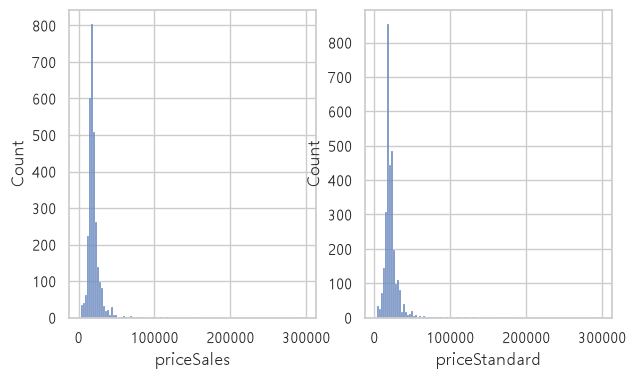

author
호메로스                                      27
유시민                                       14
이정기, 타블라라사 편집부                            13
김종원                                       12
히가시노 게이고                                  11
일본보그사                                     10
유홍준                                        9
칼 세이건                                      9
김진우, 박종우, 장용익, 이인섭, 맹형규, 정재일, 한지우, 유태용     8
이꽃님                                        8
Name: count, dtype: int64

In [ ]:
books.describe(exclude='number')
# 전체 도서 3000권 (카테고리 별 베스트 셀러 200권씩 이라 중복 도서 빼면 2546권)
# 작가 2546명, 출판사 842개
# 전체 카테고리 15개 (카테고리별로 뽑음)
print(books.describe())
#평균 정가 21377.54, 평균 판매가 19306717
#평균 평점 8.2
#판매지수 평균 12305
#가격분포 (히스토그램)
fig, ax= plt.subplots(1,2,figsize=(7,4))
sns.histplot(books['priceSales'],ax=ax[0])
sns.histplot(books['priceStandard'],ax=ax[1])
plt.show()



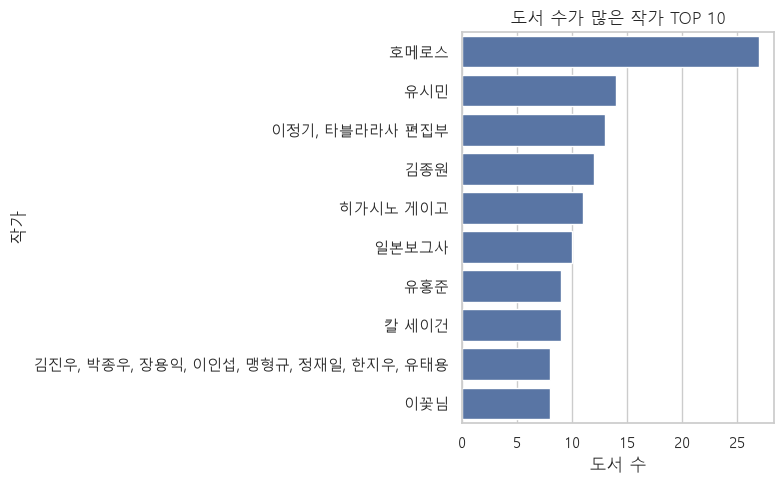

In [ ]:
#작가 top10
books['author']=books['author'].str.strip()
top10 = books["author"].value_counts().head(10).index

fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(
    data=books[books["author"].isin(top10)],
    y="author",
    order=top10,
    ax=ax
)

ax.set_title("도서 수가 많은 작가 TOP 10")
ax.set_xlabel("도서 수")
ax.set_ylabel("작가")
plt.tight_layout()
plt.show()


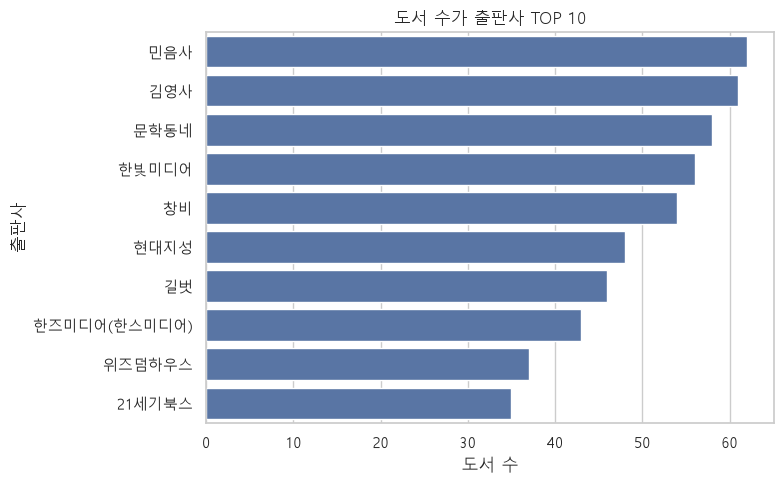

In [53]:
# 출판사 순
books['publisher']=books['publisher'].str.strip()
top10 = books["publisher"].value_counts().head(10).index

fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(
    data=books[books["publisher"].isin(top10)],
    y="publisher",
    order=top10,
    ax=ax
)

ax.set_title("도서 수가 출판사 TOP 10")
ax.set_xlabel("도서 수")
ax.set_ylabel("출판사")
plt.tight_layout()
plt.show()

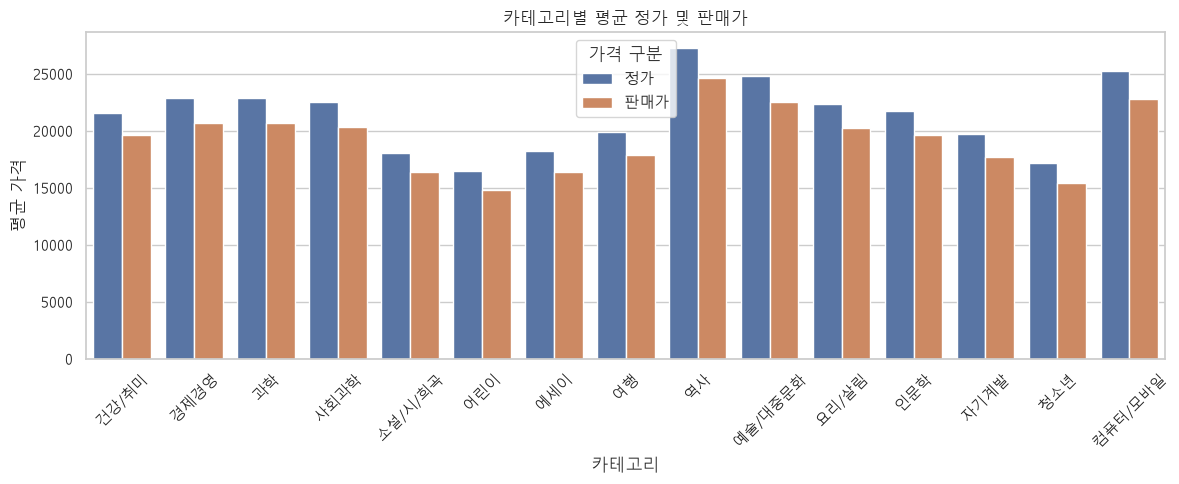

In [56]:
#카테고리 별 가격 평균(막대그래프 정가,판매가 비교)

book_price = books[
    ["category_name", "priceSales", "priceStandard"]
].copy()


price_long = book_price.melt(
    id_vars="category_name",
    value_vars=["priceStandard", "priceSales"],
    var_name="price_type",
    value_name="price"
)

price_long["price_type"] = price_long["price_type"].replace({
    "priceStandard": "정가",
    "priceSales": "판매가"
})

fig, ax = plt.subplots(figsize=(12, 5))

sns.barplot(
    data=price_long,
    x="category_name",
    y="price",
    hue="price_type",
    estimator="mean",
    errorbar=None,
    ax=ax
)

ax.set_title("카테고리별 평균 정가 및 판매가")
ax.set_xlabel("카테고리")
ax.set_ylabel("평균 가격")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="가격 구분")

plt.tight_layout()
plt.show()





In [ ]:
#카테고리 별 평점 평균

